# MEL city bikes ETL

This notebook is part of data engineering project concentrated on building **ETL pipeline** using open datasets from the **detaMEL/Lille Metropole Open Data**.

---

## Table of Contents
1. Introduction
2. Database Connection
3. ETL Job Overview
4. Results in Database
5. Next Steps

## 1. Introduction

This section of the project covers **ETL pipline creation** using **Talend**, based on the previously designed **star schema draft** for the **MEL city bikes** datasets.

---

**Licence and Usage**

These datasets are licensed under a **Licence Ouverte Etalab 2.0**.
They were downloaded on **3 December 2025**.


**Reference**

- Ilévia - *Comptages vélos depuis 2013*, dataMEL, [link↗](https://data.lillemetropole.fr/catalogue/dataset/fb7cf2fb-9466-48eb-a141-3869a4c1860b)
- Ilévia -*Populations des communes et de la MEL*, dataMEL, [link↗](https://data.lillemetropole.fr/catalogue/dataset/1106c6dc-a5ec-4eb8-a4e0-9cc813a2aeda)
- Ilévia -*Communes et communes associées de la Métropole Européenne de Lille*, dataMEL, [link↗](https://data.lillemetropole.fr/catalogue/dataset/25e38054-3194-46ab-ab88-f2b144ef26ed)

---

**Objective**

The goal of this stage is to extract and load the raw datasets, apply the necessary data transformation steps, and populate the target PostgreSQL database as part of the ETL workflow.

## 2. Database Connection

The process began with creating an empty PostgreSQL database. Based on the data cleaning performed in the Jupyter Notebook and the drafted star schema, SQL DDL scripts were written to create the dimension and fact tables.
The database environment was initialized using **Docker**, ensuring a clean and reproducible setup.

To connect the database to the Talend project, a new metadata database connection named `dwh` was created.
The connection was configured using context variables, which store parameters such as:

- `user`
- `password`
- `port`
- `database`
- `schema_dwh`
- `additionalParams`

Using context variables ensures that no sensitive information is hard-coded in the project and allows easy switching between environments.

In [1]:
from pathlib import Path
from IPython.display import Image, display

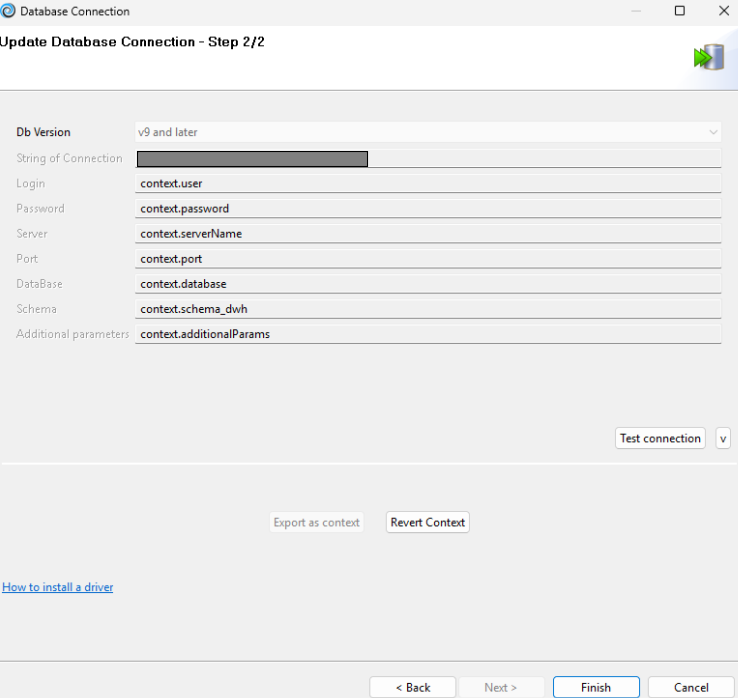

In [2]:
img_path_1 = Path().resolve().parent / "etl/db_connection.png"
display(Image(filename=img_path_1))

## 3. ETL Job Overview

### Full Job Flow

The Talend ETL job integrates multiple data sources, applies transformations, and loads the cleaned data into a PostgreSQL data warehouse structured as a star schema.

Three `tFileInputDelimited` components are used to read the CSV input datasets — `communes`, `velos`, and `populations`.
These datasets are processed and transformed in `tMap`, where column mappings, data standardization, filtering, and type conversions are applied. Finally, the transformed data is loaded into PostgreSQL using `tDBOutput` components.

**Dimension Tables:**

- `dim_commune` – contains municipality-level attributes
- `dim_capteur` – describes bicycle detection sensors
- `dim_calendar` – includes normalized date and time attributes for analytical purposes

**Fact Tables:**

- `fact_velo` – stores aggregated bicycle count information
- `fact_population` – contains demographic metrics linked to communes

The applied transformations were determined based on insights from the initial exploratory data analysis (EDA) and the prototype data cleaning performed in the Jupyter Notebook. These steps ensured that the processed datasets met the requirements of the previously designed star schema and aligned with the goals of the ETL pipeline.

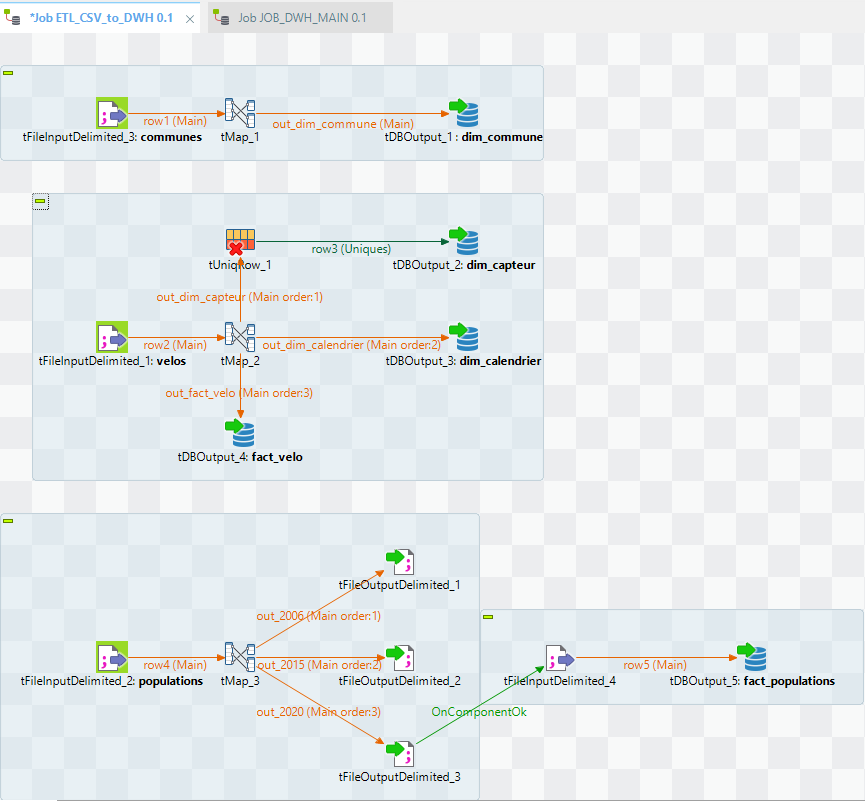

In [3]:
img_path_2 = Path().resolve().parent / "etl/ETL_CSV_to_DWH_job.png"
display(Image(filename=img_path_2))

### Input Files

File paths were configured using Talend context variables, with the folderFile parameter controlling the directory location of all raw files. This approach ensures portability and prevents hard-coding local paths into the job design.

Each dataset was assigned a custom schema within the `tFileInputDelimited` components. The schema definitions were added manually to maintain the correct column order and data types, fully aligned with the structure defined in the SQL DDL scripts and the star schema design.

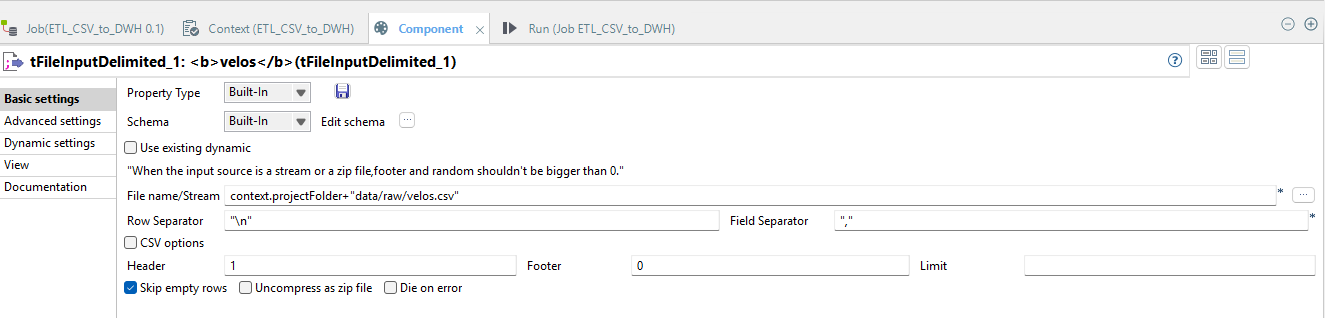

In [4]:
img_path_3 = Path().resolve().parent / "etl/tFileInputDelimited_settings_ex.png"
display(Image(filename=img_path_3))

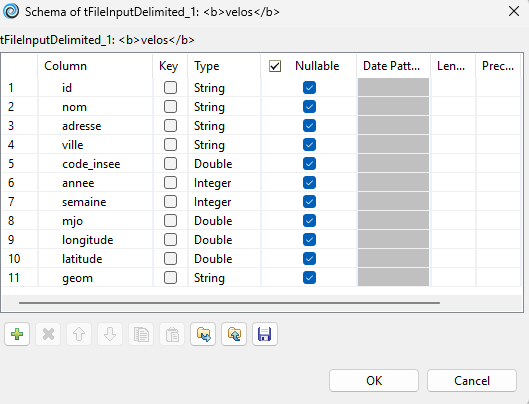

In [5]:
img_path_4 = Path().resolve().parent / "etl/tFileInputDelimited_schema_ex.png"
display(Image(filename=img_path_4))

### Transformations

Data transformations were implemented primarily in the `tMap` component, with additional preprocessing performed using `tUniqRow`, depending on the structure and requirements of each dataset.

**Unique Key Extraction:**

The `tUniqRow` component was used to extract the unique sensor identifiers required for building the `dim_capteur` table. This ensured that only distinct sensor records were included in the dimension table.

**tMap Transformations:**

Most transformation logic was implemented inside `tMap`, including:

- **Value Imputations** - handling missing or inconsistent values using conditional expressions:
  
  `e.g. row2.code_insee != null ? row2.code_insee : ("VILLENEUVE-D ASCQ".equals(row2.ville) ? 59009 : 0`
  
- **Column Selection** - selecting only the attributes necessary for the star schema and downstream fact/dimension tables
  
- **New Column Creation** - deriving new analytical attributes, such as composite keys or concatenated fields:

    `String.valueOf(row2.annee) + "_" + String.valueOf(row2.semaine)`

- **Row Filtering** - filtering out invalid, incomplete, or irrelevant rows to ensure data quality:

    `row4.code_insee != null && row4.code_insee != 0`

For the `fact_population` table, the `tMap` component was used to generate three separate outputs, each corresponding to a different subset or transformation of the population dataset.
These outputs were later combined into a single long-format table (similar to the effect of `pandas.melt`) before being loaded into the database.

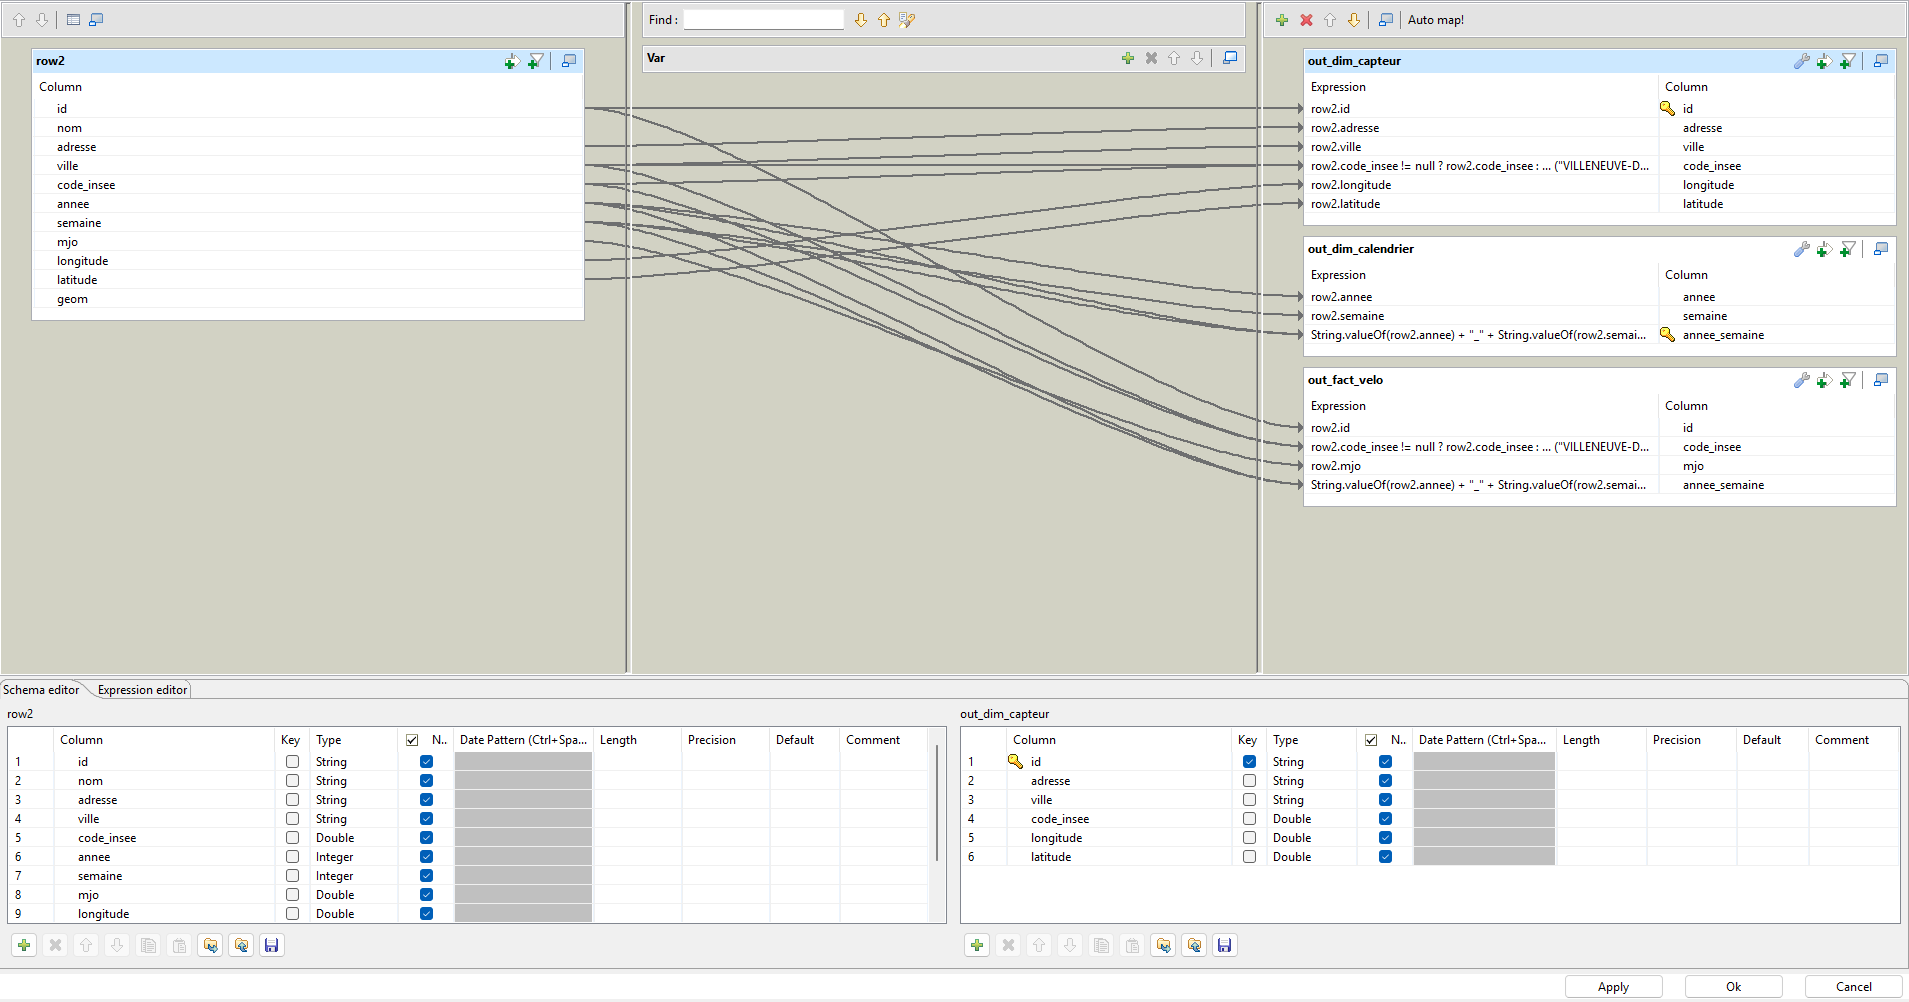

In [7]:
img_path_5 = Path().resolve().parent / "etl/tMap_mapping_transformation_ex.png"
display(Image(filename=img_path_5))

### Output / Load

The final dimension and fact tables were loaded into the PostgreSQL database using the **tDBOutput** component.
Each `tDBOutput` component automatically inherits the connection parameters previously defined in the Metadata repository (database name, host, port, user, etc.), ensuring consistent and centralized configuration management.
The only parameter selected manually within each component is the target table name.

Data is written to the database using the **Insert** action, meaning that the process performs insert-only loads without updating existing records. This behavior fits the structure of the pipeline, which is designed to load cleaned and transformed datasets into an empty or freshly initialized schema.

Before executing the job, Talend performs a schema compatibility check, comparing each component’s output schema with the structure of the target tables in the database. This verification step ensures that column definitions, data types, and ordering match the design specified in the DDL scripts and the ETL pipeline configuration.

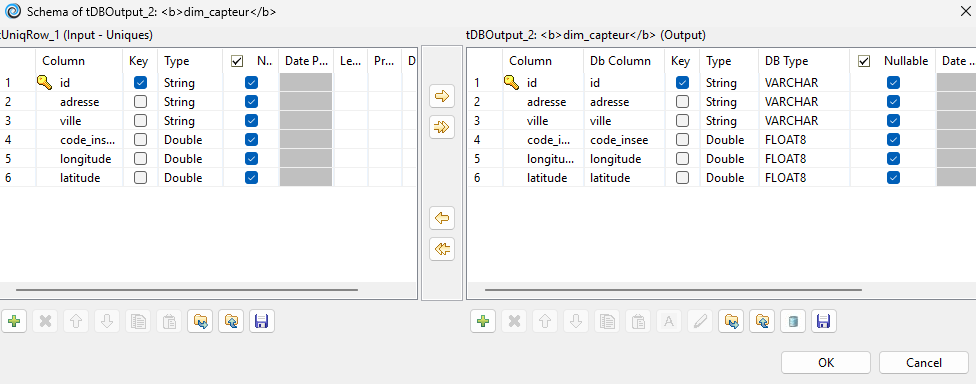

In [8]:
img_path_6 = Path().resolve().parent / "etl/tDBOutput_schema_ex.png"
display(Image(filename=img_path_6))

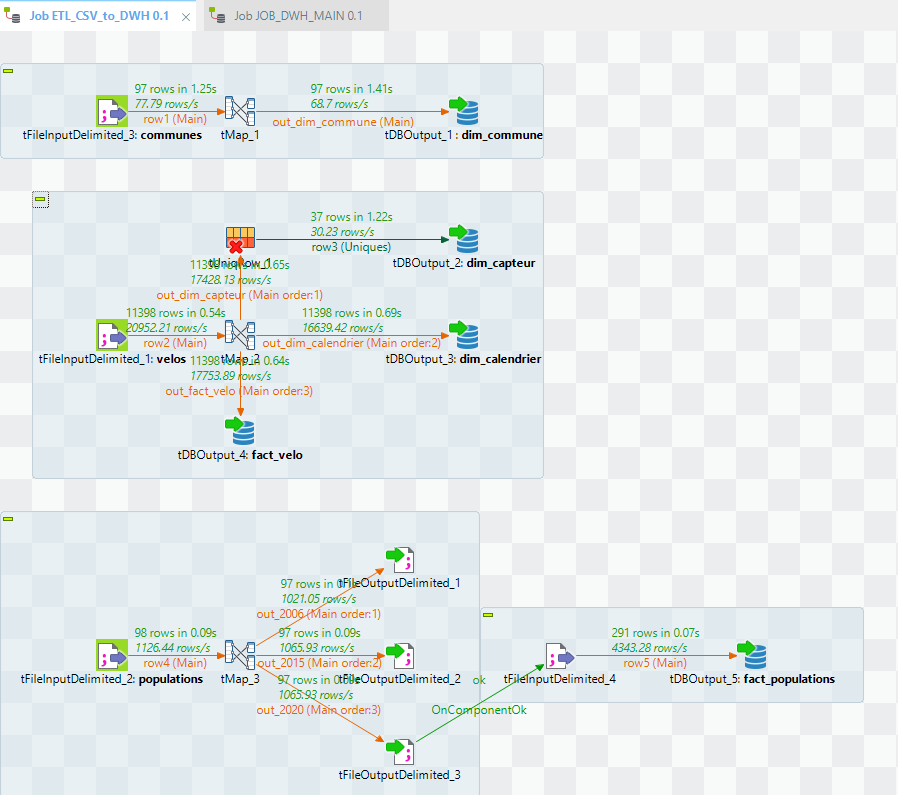

In [9]:
img_path_7 = Path().resolve().parent / "etl/ETL_CSV_to_DWH_run_job.png"
display(Image(filename=img_path_7))

## 4. Results in Database

After executing the ETL pipeline, the PostgreSQL data warehouse contains **five fully populated tables** — three dimension tables and two fact tables — structured according to the previously defined star schema.
All primary and foreign key relationships were created during the database setup (via SQL DDL scripts) and validated during loading.

The resulting tables are:

**Dimension Tables:**

- `dim_commune` – municipal-level attributes
- `dim_capteur` – bicycle sensor metadata
- `dim_calendrier` – standardized date and time attributes

**Fact Tables:**

- `fact_velo` – processed bicycle count observations
- `fact_population` – demographic measures linked to communes

Screenshots below illustrate sample records from each table in the PostgreSQL environment, confirming that the ETL process successfully loaded the transformed datasets into the star schema.

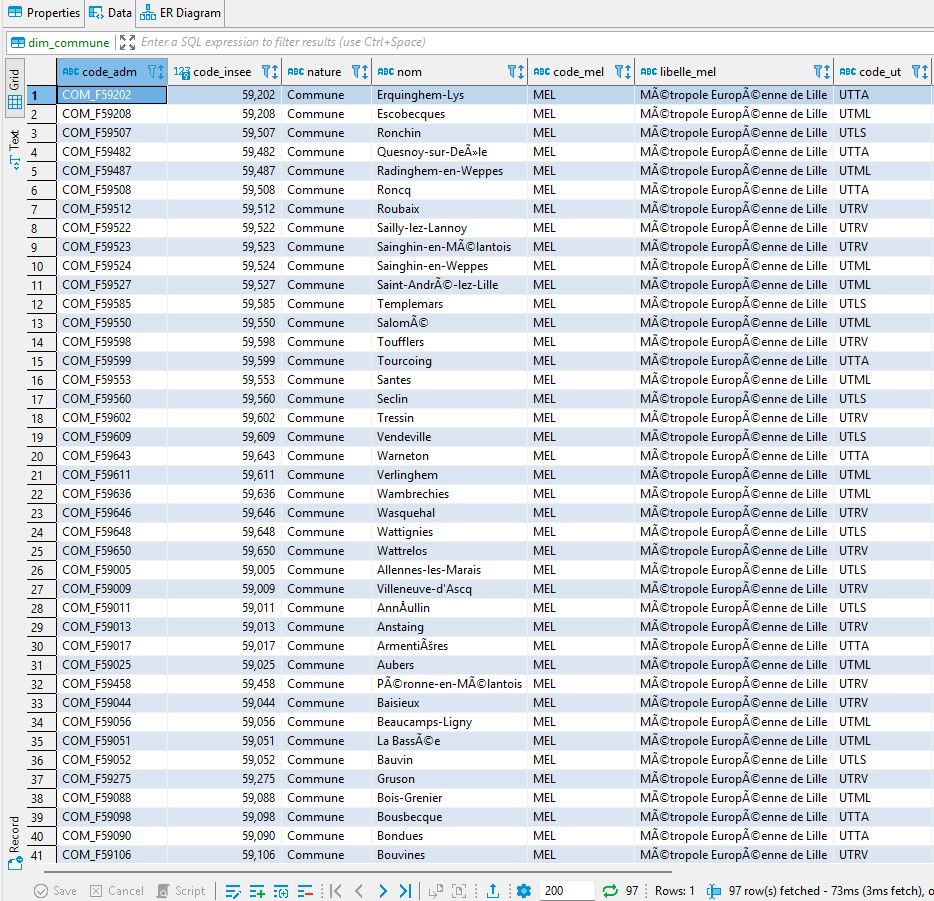

In [10]:
img_path_8 = Path().resolve().parent / "dwh/dim_commune.png"
display(Image(filename=img_path_8))

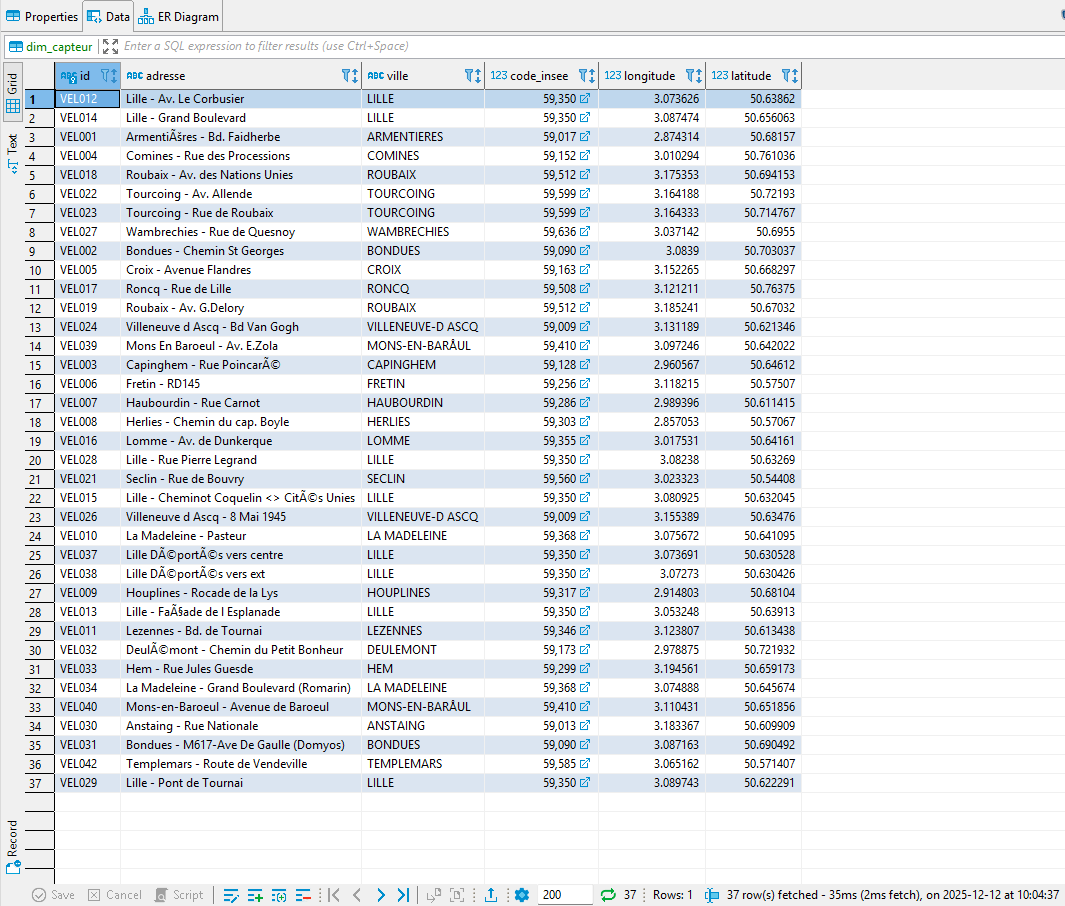

In [11]:
img_path_9 = Path().resolve().parent / "dwh/dim_capteur.png"
display(Image(filename=img_path_9))

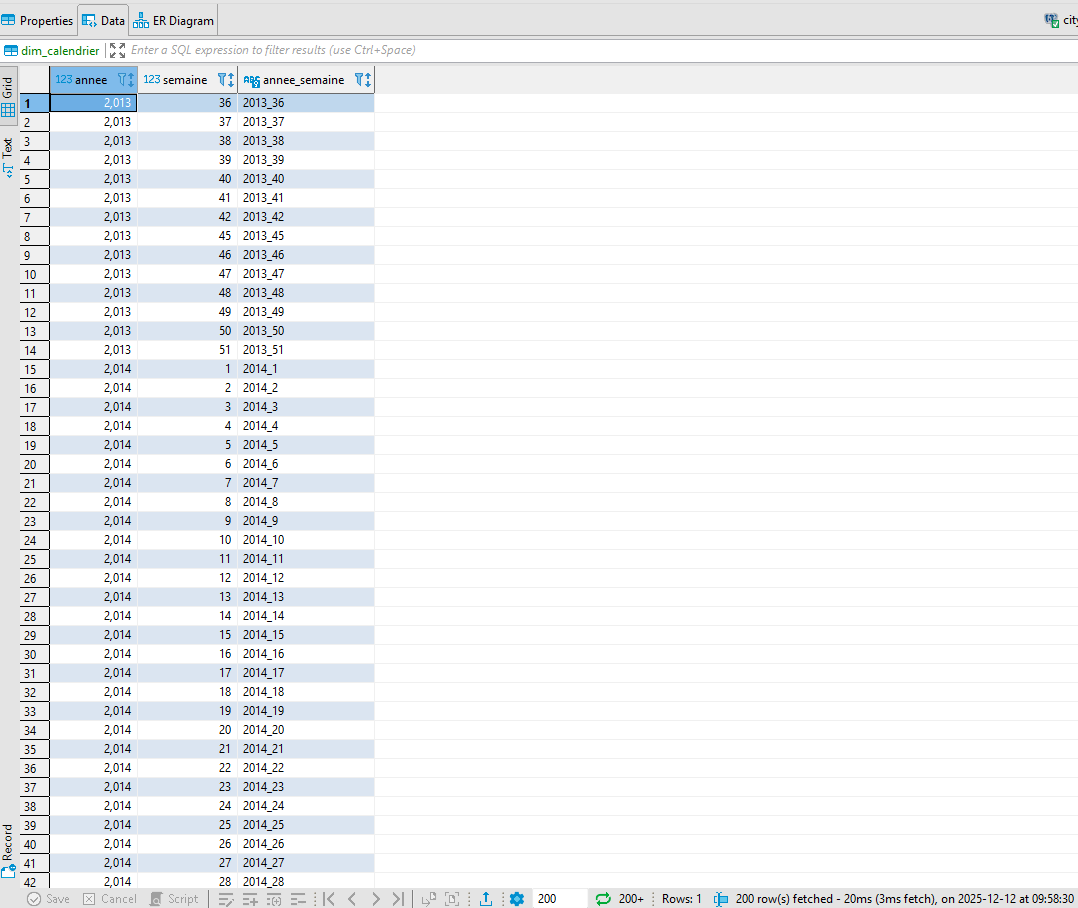

In [12]:
img_path_10 = Path().resolve().parent / "dwh/dim_calendrier.png"
display(Image(filename=img_path_10))

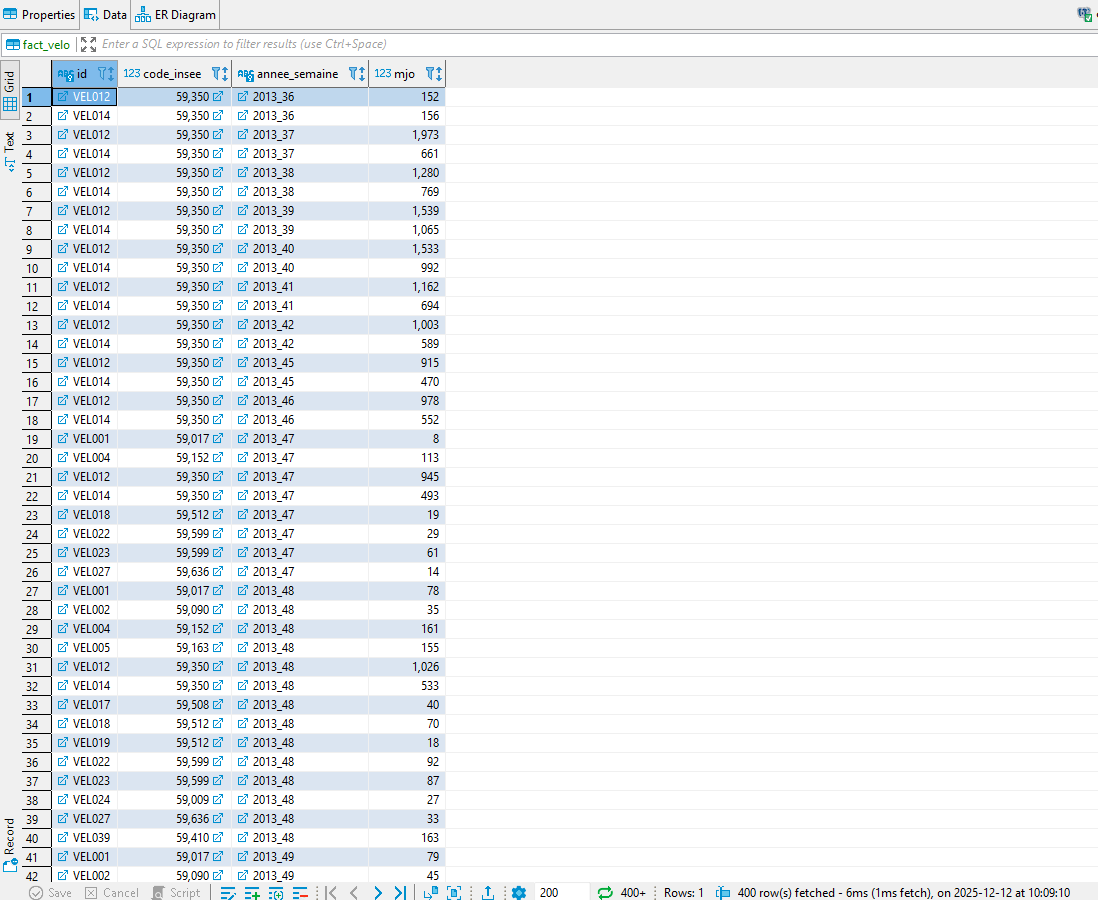

In [13]:
img_path_11 = Path().resolve().parent / "dwh/fact_velo.png"
display(Image(filename=img_path_11))

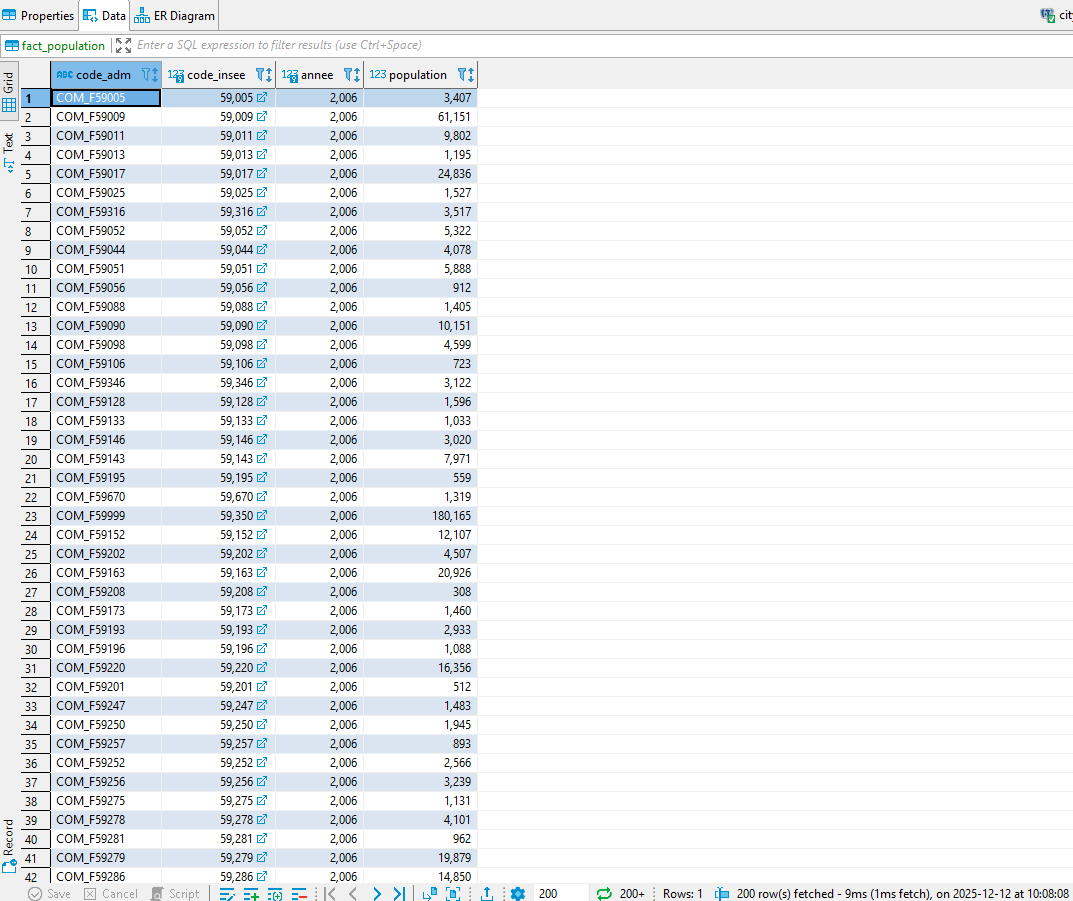

In [14]:
img_path_12 = Path().resolve().parent / "dwh/fact_population.png"
display(Image(filename=img_path_12))

## 5. Next Steps

Based on the initial data exploration and profiling, several enhancements can be implemented in the future iterations of this ETL project:

   - **Schedule automated ETL execution** using a job scheduler (e.g., cron or orchestration tool) to ensure regular and reproducible pipline runs.
   - **Connect the PostgreSQL data warehouse to Power BI** to build an interactive analytical dashboard and visualize key indicators.
   - **Enrich the data model with contextual datasets** (e.g., schools, parks, hospitals) to iexpand analytical depth and support more complex use cases.